# 1 データインポートと前処理

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson, norm
from sklearn.linear_model import PoissonRegressor, Ridge, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, log_loss
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report



# 1. データの読み込みと前処理
df = pd.read_csv('/Users/akihirookuyama/Soccer_Score_App/Data/ML_dataset.csv')

# 特徴量と目的変数の分離
# Sectionはバイアス回避のため、Season/Date/Scoreなどはリーク回避のため削除。
# Home, Away, Stadiumなどは特徴量重要度が低かったので、除外対象とする。
drop_cols = ['Season', 'Section', 'Date', 'Score', 'Home', 'Away', 'Stadium',
             'Home_Goals', 'Away_Goals', 'Goal_Diff', 'Match_Result']
X = df.drop(columns=drop_cols)

# One-Hot Encodingの対象を明示的に指定
cat_cols = [
    'Weather', 
    'Backline_Matchup', 
    'Home_Formation', 
    'Away_Formation'
]
# 指定したカラムのみダミー変数化を実行
X = pd.get_dummies(X, columns=cat_cols)

print(f"変換後の特徴量数: {X.shape[1]}")
# 数値データ（Elo等）が保持され、チーム名やスタジアム名だけが展開されていることを確認

# ターゲット変数の準備
y_goals = df[['Home_Goals', 'Away_Goals']]
y_result = df['Match_Result']
y_diff = df['Goal_Diff']

変換後の特徴量数: 164


# 2 学習データ、テストデータの準備

In [13]:

# 2. データの分割 (2021-2024: 学習, 2025: テスト)

train_mask = df['Season'] < 2025
test_mask = df['Season'] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_goals_train, y_goals_test = y_goals[train_mask], y_goals[test_mask]
y_result_train, y_result_test = y_result[train_mask], y_result[test_mask]
y_diff_train, y_diff_test = y_diff[train_mask], y_diff[test_mask]

print(f"特徴量数: {X.shape[1]}")
print(f"学習データ数: {len(X_train)}, テストデータ数: {len(X_test)}")

特徴量数: 164
学習データ数: 1372, テストデータ数: 380


# 3 Step1 得点予測モデル構築

In [14]:
# 3. Step 1: 個別得点予測 (回帰)
print("\n[Step 1] 得点予測モデルの比較 (MAE)")

# A. ポアソン回帰 (得点の性質に特化した統計モデル)
# MultiOutputRegressorでHome/Awayを同時に学習
model_step1_poisson = MultiOutputRegressor(PoissonRegressor()).fit(X_train, y_goals_train)
pred_step1_poisson = model_step1_poisson.predict(X_test)
mae_poisson = mean_absolute_error(y_goals_test, pred_step1_poisson)

# B. LightGBM Regressor (非線形な関係に強い)
model_step1_lgb = MultiOutputRegressor(lgb.LGBMRegressor(random_state=42)).fit(X_train, y_goals_train)
pred_step1_lgb = model_step1_lgb.predict(X_test)
mae_step1_lgb = mean_absolute_error(y_goals_test, pred_step1_lgb)

print(f"  - Poisson Regressor MAE: {mae_poisson:.4f}")
print(f"  - LightGBM Regressor MAE: {mae_step1_lgb:.4f}")


[Step 1] 得点予測モデルの比較 (MAE)


/Users/akihirookuyama/Soccer_Score_App/.venv/lib/python3.10/site-packages/sklearn/linear_model/_glm/glm.py:286: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


  - Poisson Regressor MAE: 0.9040
  - LightGBM Regressor MAE: 0.8909


# 4 Step2　勝敗＆得失点差予測モデルの構築

In [15]:
# 4. Step 2: 展開予測 (分類 & 点差回帰)

print("\n[Step 2] 展開予測モデルの比較")

# A. 勝敗分類 (Logistic vs LightGBM)
model_step2_logi = LogisticRegression(max_iter=1000).fit(X_train, y_result_train)
model_step2_clf_lgb = lgb.LGBMClassifier(random_state=42).fit(X_train, y_result_train)

acc_logi = accuracy_score(y_result_test, model_step2_logi.predict(X_test))
acc_lgb = accuracy_score(y_result_test, model_step2_clf_lgb.predict(X_test))
loss_lgb = log_loss(y_result_test, model_step2_clf_lgb.predict_proba(X_test))

print(f"  - 勝敗分類 Accuracy (Logistic): {acc_logi:.4f}")
print(f"  - 勝敗分類 Accuracy (LightGBM): {acc_lgb:.4f}")

# B. 得点差回帰
model_step2_diff_lgb = lgb.LGBMRegressor(random_state=42).fit(X_train, y_diff_train)
mae_diff_lgb = mean_absolute_error(y_diff_test, model_step2_diff_lgb.predict(X_test))
print(f"  - 得点差予測 MAE (LightGBM): {mae_diff_lgb:.4f}")


[Step 2] 展開予測モデルの比較


/Users/akihirookuyama/Soccer_Score_App/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  - 勝敗分類 Accuracy (Logistic): 0.4263
  - 勝敗分類 Accuracy (LightGBM): 0.5000
  - 得点差予測 MAE (LightGBM): 1.1172


# 5 結論

上記の結果から、Step1、Step2ともに**LGBMを採用**する。
ここからは、それぞれのモデルのハイパーパラメータチューニングを実施する

# 6 ハイパーパラメータチューニング

In [16]:

# 0. 時系列分割の設定 (例: 3分割)

# データを過去から順番に増やしながら検証します
# 例: [Fold 1] Train: 2021, Val: 2022
#     [Fold 2] Train: 2021-2022, Val: 2023
#     [Fold 3] Train: 2021-2023, Val: 2024
tscv = TimeSeriesSplit(n_splits=3)


# 1. Step 2-A: 勝敗分類 (Classifier) のチューニング

def objective_step2_clf(trial):
    # 探索するパラメータの範囲を定義
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'verbosity': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300)
    }

    accuracies = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_result_train.iloc[train_idx], y_result_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        
        # 学習 (Early Stopping を使用して過学習を防ぐ)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )

        preds = model.predict(X_va)
        acc = accuracy_score(y_va, preds)
        accuracies.append(acc)

    # 3回の交差検証の平均Accuracyを返す
    return np.mean(accuracies)



# 2. Step 2-B: 得点差予測 (Regressor) のチューニング

def objective_step2_diff_reg(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'verbosity': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) # 得点差は回帰なので少し多めに探索
    }

    diff_maes = []

    # 時系列交差検証
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_diff_train.iloc[train_idx], y_diff_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        
        # Early Stoppingで過学習を防ぐ
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )

        preds = model.predict(X_va)
        mae = mean_absolute_error(y_va, preds)
        diff_maes.append(mae)

    return np.mean(diff_maes)



# 3. Step 1: 得点予測 (Regressor) のチューニング
def objective_step1_reg(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'verbosity': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300)
    }

    maes = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_goals_train.iloc[train_idx], y_goals_train.iloc[val_idx]

        # MultiOutputRegressorで包むため、Early Stoppingは直接使わずに学習
        # (Optunaのn_estimators探索に委ねる)
        base_model = lgb.LGBMRegressor(**params)
        model = MultiOutputRegressor(base_model)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_va)
        mae = mean_absolute_error(y_va, preds)
        maes.append(mae)

    return np.mean(maes)


# 4. チューニングの実行
print("--- Step 2 (勝敗分類) のチューニング開始 ---")
study_clf = optuna.create_study(direction='maximize') # Accuracyは最大化
study_clf.optimize(objective_step2_clf, n_trials=100) 

print("\n--- Step 2-B (得点差予測) のチューニング開始 ---")
study_diff = optuna.create_study(direction='minimize') # MAEは最小化
study_diff.optimize(objective_step2_diff_reg, n_trials=100)

print("\n--- Step 1 (得点予測) のチューニング開始 ---")
study_reg = optuna.create_study(direction='minimize') # MAEは最小化
study_reg.optimize(objective_step1_reg, n_trials=100)


# 結果の表示
print("\n=== チューニング結果 ===")
print(f"勝敗分類 ベストAccuracy: {study_clf.best_value:.4f}")
print(f"勝敗分類 ベストパラメータ: {study_clf.best_params}")

print(f"\n得点差予測 ベストMAE: {study_diff.best_value:.4f}")
print(f"得点差予測 ベストパラメータ: {study_diff.best_params}")

print(f"\n得点予測 ベストMAE: {study_reg.best_value:.4f}")
print(f"得点予測 ベストパラメータ: {study_reg.best_params}")

[I 2026-05-02 14:03:20,841] A new study created in memory with name: no-name-a032a608-b150-4006-8f11-b57bc452ed1f


--- Step 2 (勝敗分類) のチューニング開始 ---


[I 2026-05-02 14:03:23,355] Trial 0 finished with value: 0.48882410106899904 and parameters: {'learning_rate': 0.014603195301663376, 'max_depth': 9, 'num_leaves': 83, 'min_child_samples': 45, 'subsample': 0.8708141467598065, 'colsample_bytree': 0.9579690579206659, 'n_estimators': 227}. Best is trial 0 with value: 0.48882410106899904.
[I 2026-05-02 14:03:24,149] Trial 1 finished with value: 0.49659863945578236 and parameters: {'learning_rate': 0.09171611279925035, 'max_depth': 8, 'num_leaves': 68, 'min_child_samples': 37, 'subsample': 0.6326062446584353, 'colsample_bytree': 0.7371809073429799, 'n_estimators': 80}. Best is trial 1 with value: 0.49659863945578236.
[I 2026-05-02 14:03:25,307] Trial 2 finished with value: 0.49368318756073853 and parameters: {'learning_rate': 0.02522054324848376, 'max_depth': 4, 'num_leaves': 79, 'min_child_samples': 45, 'subsample': 0.8279582749514001, 'colsample_bytree': 0.9691522422143178, 'n_estimators': 157}. Best is trial 1 with value: 0.49659863945578


--- Step 2-B (得点差予測) のチューニング開始 ---


[I 2026-05-02 14:05:28,082] Trial 0 finished with value: 1.1648397073595256 and parameters: {'learning_rate': 0.008270102436465573, 'max_depth': 7, 'num_leaves': 35, 'min_child_samples': 16, 'subsample': 0.8657503142657168, 'colsample_bytree': 0.6552752541905599, 'n_estimators': 303}. Best is trial 0 with value: 1.1648397073595256.
[I 2026-05-02 14:05:28,997] Trial 1 finished with value: 1.148054488701795 and parameters: {'learning_rate': 0.01179131862047973, 'max_depth': 4, 'num_leaves': 18, 'min_child_samples': 45, 'subsample': 0.6714645511934009, 'colsample_bytree': 0.9335015349515252, 'n_estimators': 364}. Best is trial 1 with value: 1.148054488701795.
[I 2026-05-02 14:05:30,343] Trial 2 finished with value: 1.1556840104912303 and parameters: {'learning_rate': 0.011714769727988543, 'max_depth': 6, 'num_leaves': 34, 'min_child_samples': 32, 'subsample': 0.8051099944681248, 'colsample_bytree': 0.9032541422962406, 'n_estimators': 349}. Best is trial 1 with value: 1.148054488701795.
[I


--- Step 1 (得点予測) のチューニング開始 ---


[I 2026-05-02 14:06:47,104] Trial 0 finished with value: 0.9492097881305804 and parameters: {'learning_rate': 0.05846121656939185, 'max_depth': 9, 'num_leaves': 93, 'min_child_samples': 10, 'subsample': 0.9249629304314028, 'colsample_bytree': 0.9784656727797025, 'n_estimators': 77}. Best is trial 0 with value: 0.9492097881305804.
[I 2026-05-02 14:06:50,615] Trial 1 finished with value: 0.9461765458345309 and parameters: {'learning_rate': 0.05645988671328314, 'max_depth': 7, 'num_leaves': 58, 'min_child_samples': 23, 'subsample': 0.6696796477942043, 'colsample_bytree': 0.9391684181890473, 'n_estimators': 245}. Best is trial 1 with value: 0.9461765458345309.
[I 2026-05-02 14:06:51,280] Trial 2 finished with value: 0.8824858544902116 and parameters: {'learning_rate': 0.01845318418845373, 'max_depth': 5, 'num_leaves': 84, 'min_child_samples': 45, 'subsample': 0.7431290999817549, 'colsample_bytree': 0.6579318514356288, 'n_estimators': 70}. Best is trial 2 with value: 0.8824858544902116.
[I 


=== チューニング結果 ===
勝敗分類 ベストAccuracy: 0.5102
勝敗分類 ベストパラメータ: {'learning_rate': 0.05335428270903498, 'max_depth': 9, 'num_leaves': 36, 'min_child_samples': 45, 'subsample': 0.6151065475512765, 'colsample_bytree': 0.7599882132567581, 'n_estimators': 257}

得点差予測 ベストMAE: 1.1417
得点差予測 ベストパラメータ: {'learning_rate': 0.026706019216521316, 'max_depth': 5, 'num_leaves': 24, 'min_child_samples': 41, 'subsample': 0.6619772464782415, 'colsample_bytree': 0.6023897947653992, 'n_estimators': 385}

得点予測 ベストMAE: 0.8803
得点予測 ベストパラメータ: {'learning_rate': 0.012322537859458825, 'max_depth': 9, 'num_leaves': 10, 'min_child_samples': 35, 'subsample': 0.9667197761559129, 'colsample_bytree': 0.7694855488360749, 'n_estimators': 116}


# 7 ベストパラメータで再学習・評価

In [17]:
# 1. Step 1: 得点予測モデル (MultiOutput LGBM)

print("--- Step 1: 得点予測モデル 再学習中 ---")
# MultiOutputRegressor の場合、中のベースモデルにパラメータを渡します
base_reg_model = lgb.LGBMRegressor(**study_reg.best_params, random_state=42, verbosity=-1)
model_step1_goals = MultiOutputRegressor(base_reg_model)
model_step1_goals.fit(X_train, y_goals_train)

# 予測と評価
y_pred_goals = model_step1_goals.predict(X_test)
mae_goals = mean_absolute_error(y_goals_test, y_pred_goals)


# 2. Step 2-A: 勝敗分類モデル (LGBM Classifier)
print("--- Step 2-A: 勝敗分類モデル 再学習中 ---")
model_step2_clf = lgb.LGBMClassifier(**study_clf.best_params, random_state=42, verbosity=-1)
model_step2_clf.fit(X_train, y_result_train)

# 予測と評価
y_pred_result = model_step2_clf.predict(X_test)
acc_result = accuracy_score(y_result_test, y_pred_result)



# 3. Step 2-B: 得点差予測モデル (LGBM Regressor)
print("--- Step 2-B: 得点差予測モデル 再学習中 ---")
model_step2_diff = lgb.LGBMRegressor(**study_diff.best_params, random_state=42, verbosity=-1)
model_step2_diff.fit(X_train, y_diff_train)

# 予測と評価
y_pred_diff = model_step2_diff.predict(X_test)
mae_diff = mean_absolute_error(y_diff_test, y_pred_diff)



# 最終レポートの表示

print("\n" + "="*40)
print("テストデータにおける最終評価レポート")
print("="*40)
print(f"【Step 1】得点予測 MAE: {mae_goals:.4f}")
print(f"【Step 2-A】勝敗的中率 Accuracy: {acc_result:.4f}")
print(f"【Step 2-B】得点差予測 MAE: {mae_diff:.4f}")
print("-" * 40)
print("■ 勝敗分類の詳細（クラス別精度）:")
print(classification_report(y_result_test, y_pred_result, target_names=['Away Win', 'Draw', 'Home Win']))

--- Step 1: 得点予測モデル 再学習中 ---
--- Step 2-A: 勝敗分類モデル 再学習中 ---
--- Step 2-B: 得点差予測モデル 再学習中 ---

テストデータにおける最終評価レポート
【Step 1】得点予測 MAE: 0.8514
【Step 2-A】勝敗的中率 Accuracy: 0.4921
【Step 2-B】得点差予測 MAE: 1.0638
----------------------------------------
■ 勝敗分類の詳細（クラス別精度）:
              precision    recall  f1-score   support

    Away Win       0.47      0.62      0.54       115
        Draw       0.24      0.15      0.19        97
    Home Win       0.60      0.60      0.60       168

    accuracy                           0.49       380
   macro avg       0.44      0.46      0.44       380
weighted avg       0.47      0.49      0.48       380



# 8 Step3 最終結果の出力

In [18]:
def finalize_score(lambda_h, lambda_a, prob_win, prob_draw, prob_lose, pred_diff, max_goals=5):
    best_s = -1
    final_score = (0, 0)
    
    # 0点〜max_goals点の全パターンを検証
    for gh in range(max_goals + 1):
        for ga in range(max_goals + 1):
            # ① Step 1: ポアソン確率
            p_gh = poisson.pmf(gh, lambda_h)
            p_ga = poisson.pmf(ga, lambda_a)
            p_base = p_gh * p_ga
            
            # ② Step 2-A: 勝敗確率による補正
            if gh > ga:
                w_result = prob_win
            elif gh == ga:
                w_result = prob_draw
            else:
                w_result = prob_lose
                
            # ③ Step 2-B: 点差予測による補正 (ガウス分布を使用)
            # 実際の点差と予測点差の乖離をペナルティ化
            l_diff = norm.pdf(gh - ga, loc=pred_diff, scale=1.0) 
            
            # 最終的な「納得度スコア」
            current_s = p_base * w_result * l_diff
            
            if current_s > best_s:
                best_s = current_s
                final_score = (gh, ga)
                
    return final_score

# --- 全テストデータに適用 ---
y_final_preds = []

# 各モデルの予測値を取得
# Step 1: 目標得点の期待値 (lambda)
step1_preds = model_step1_goals.predict(X_test) 
# Step 2-A: 勝敗確率 (Away, Draw, Home の順と想定)
step2a_probs = model_step2_clf.predict_proba(X_test)
# Step 2-B: 予測点差
step2b_preds = model_step2_diff.predict(X_test)

for i in range(len(X_test)):
    gh_lambda, ga_lambda = step1_preds[i]
    p_lose, p_draw, p_win = step2a_probs[i]
    p_diff = step2b_preds[i]
    
    score = finalize_score(gh_lambda, ga_lambda, p_win, p_draw, p_lose, p_diff)
    y_final_preds.append(score)

y_final_preds = np.array(y_final_preds)

In [19]:
# 最終スコア完全的中率 (Exact Match Rate)
# 実際のスコア
y_true_scores = y_goals_test.values

# 正解率 (Exact Match Rate)
emr = np.all(y_final_preds == y_true_scores, axis=1).mean()

print(f"最終スコア完全的中率 (EMR): {emr:.4f}")

# 個別の得点 MAE も確認
mae_h = mean_absolute_error(y_true_scores[:, 0], y_final_preds[:, 0])
mae_a = mean_absolute_error(y_true_scores[:, 1], y_final_preds[:, 1])
print(f"最終 Home MAE: {mae_h:.4f}")
print(f"最終 Away MAE: {mae_a:.4f}")

最終スコア完全的中率 (EMR): 0.1763
最終 Home MAE: 0.9132
最終 Away MAE: 0.8421


In [20]:
# 1. 予測スコアから勝敗を抽出 (1: Home Win, 0: Draw, -1: Away Win)
def get_result_from_score(score_array):
    results = []
    for h, a in score_array:
        if h > a:
            results.append(1)
        elif h == a:
            results.append(0)
        else:
            results.append(-1)
    return np.array(results)

# 2. 最終予測スコアと実際のスコアから結果を算出
y_final_result_preds = get_result_from_score(y_final_preds)
y_true_results = get_result_from_score(y_true_scores)

# 3. 的中率の計算
final_accuracy = accuracy_score(y_true_results, y_final_result_preds)

print(f"最終統合モデルによる勝敗的中率: {final_accuracy:.4f}")

# Step 2-A 単体の結果と比較
print(f"(参考) Step 2-A 単体の的中率: {acc_result:.4f}")

最終統合モデルによる勝敗的中率: 0.4921
(参考) Step 2-A 単体の的中率: 0.4921


# 9 予測傾向の分析

/var/folders/y7/ts7mk99d73ddtqj53zy_83pm0000gn/T/ipykernel_59669/3906439519.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x='Importance', y='Feature', data=top_df, palette='viridis')
/var/folders/y7/ts7mk99d73ddtqj53zy_83pm0000gn/T/ipykernel_59669/3906439519.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x='Importance', y='Feature', data=top_df, palette='viridis')
/var/folders/y7/ts7mk99d73ddtqj53zy_83pm0000gn/T/ipykernel_59669/3906439519.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=

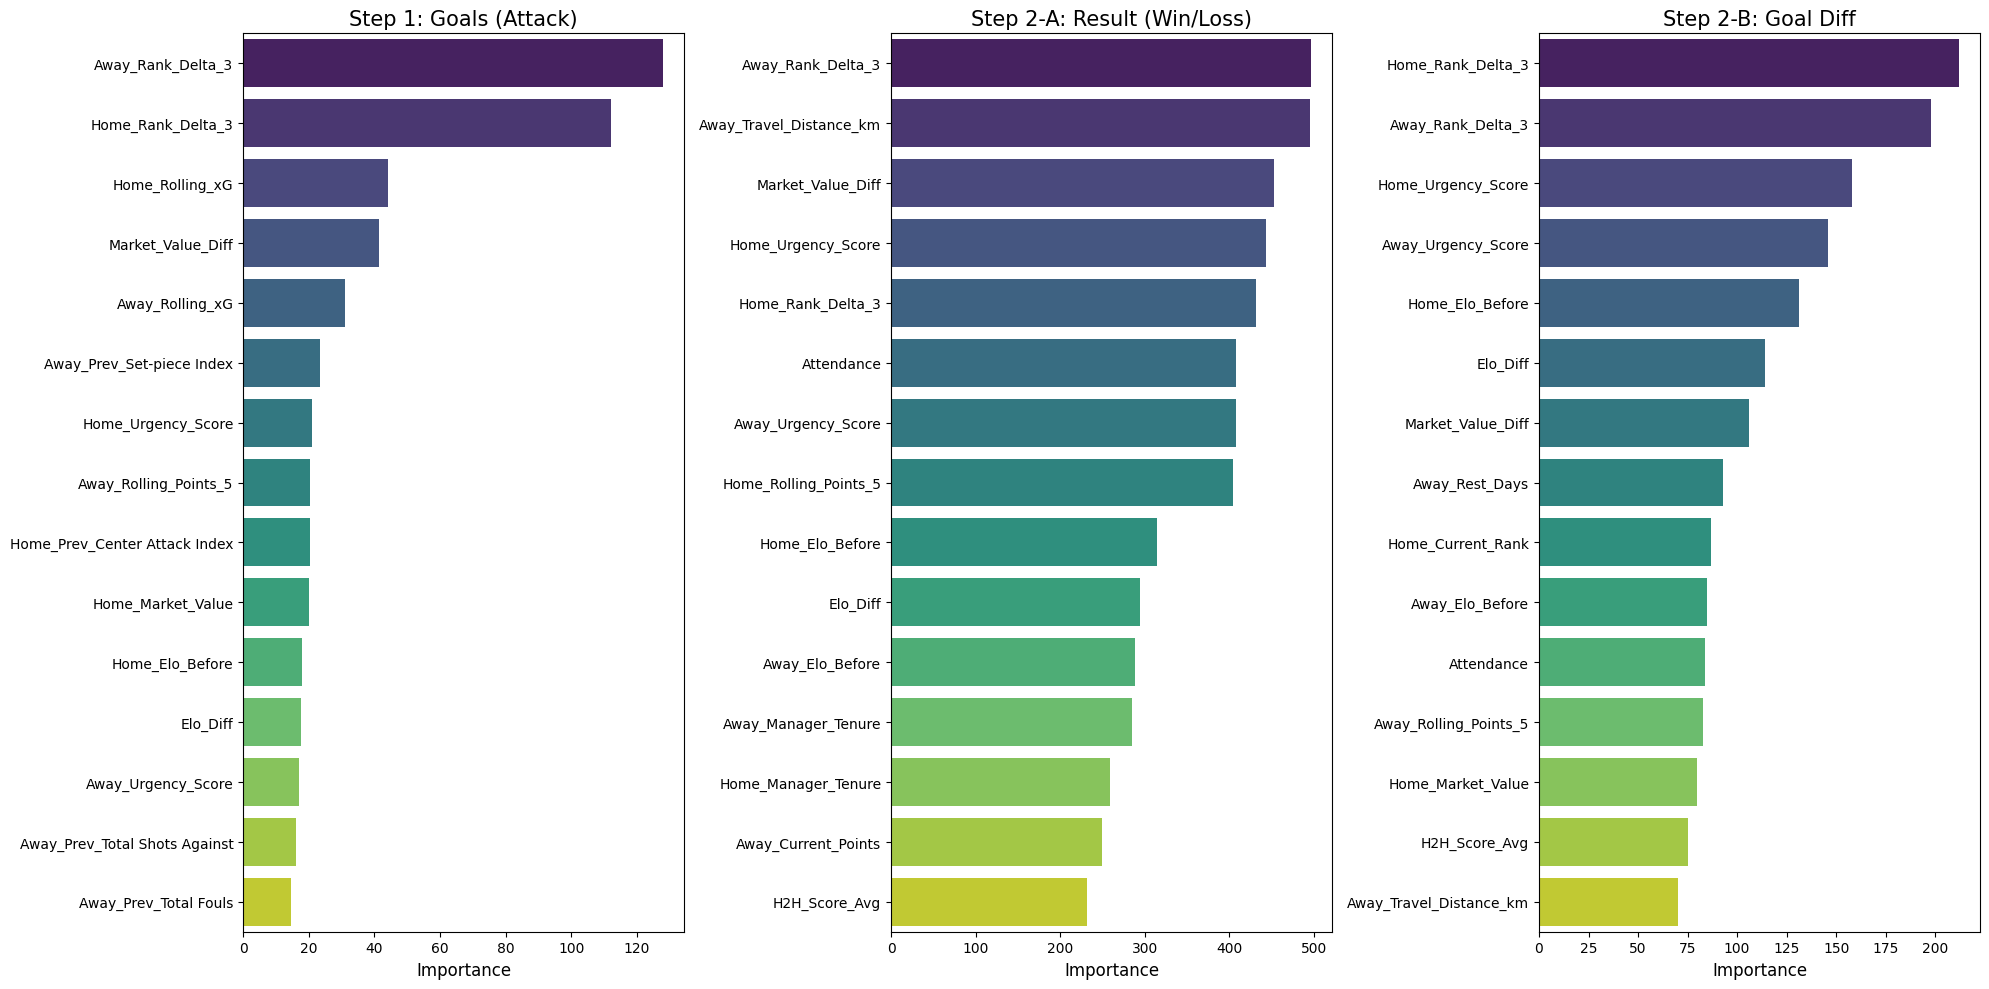


--- Step1_Goals TOP 10 ---
                           Feature  Importance
8                Away_Rank_Delta_3       128.0
7                Home_Rank_Delta_3       112.0
21                 Home_Rolling_xG        44.0
14               Market_Value_Diff        41.5
22                 Away_Rolling_xG        31.0
128      Away_Prev_Set-piece Index        23.5
137             Home_Urgency_Score        21.0
20           Away_Rolling_Points_5        20.5
112  Home_Prev_Center Attack Index        20.5
12               Home_Market_Value        20.0

--- Step2A_Result TOP 10 ---
                     Feature  Importance
8          Away_Rank_Delta_3         497
3    Away_Travel_Distance_km         496
14         Market_Value_Diff         453
137       Home_Urgency_Score         444
7          Home_Rank_Delta_3         432
0                 Attendance         408
139       Away_Urgency_Score         408
19     Home_Rolling_Points_5         404
9            Home_Elo_Before         315
11             

In [21]:
# 重要度を格納する辞書
importances = {}

# --- Step 1: 得点予測 (MultiOutputRegressorの中のLGBM) ---
# MultiOutputの場合、各ターゲットごとの重要度の平均を取ります
reg_importances = np.mean([est.feature_importances_ for est in model_step1_goals.estimators_], axis=0)
importances['Step1_Goals'] = pd.DataFrame({'Feature': X_train.columns, 'Importance': reg_importances})

# --- Step 2-A: 勝敗分類 (Classifier) ---
importances['Step2A_Result'] = pd.DataFrame({'Feature': X_train.columns, 'Importance': model_step2_clf.feature_importances_})

# --- Step 2-B: 得点差予測 (Regressor) ---
importances['Step2B_Diff'] = pd.DataFrame({'Feature': X_train.columns, 'Importance': model_step2_diff.feature_importances_})

# 可視化
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
titles = ['Step 1: Goals (Attack)', 'Step 2-A: Result (Win/Loss)', 'Step 2-B: Goal Diff']

for i, (key, df) in enumerate(importances.items()):
    top_df = df.sort_values(by='Importance', ascending=False).head(15)
    sns.barplot(ax=axes[i], x='Importance', y='Feature', data=top_df, palette='viridis')
    axes[i].set_title(titles[i], fontsize=15)
    axes[i].set_xlabel('Importance', fontsize=12)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# 数値での表示
for key in importances.keys():
    print(f"\n--- {key} TOP 10 ---")
    print(importances[key].sort_values(by='Importance', ascending=False).head(10))

In [22]:
# 重要度の低い（Bottom）特徴量を確認する関数
def display_bottom_features(importance_df, model_name, threshold_ratio=0.1):
    # 重要度の合計の10%（デフォルト）に満たない累積寄与度のものを抽出、
    # あるいは単純に重要度が低い順にソート
    df_sorted = importance_df.sort_values(by='Importance', ascending=True)
    
    print(f"\n▼ {model_name} : 重要度が低い特徴量 TOP 15")
    print(df_sorted.head(15))
    
    # 全く寄与していない（Importanceが0）ものを特定
    zero_features = df_sorted[df_sorted['Importance'] == 0]['Feature'].tolist()
    if zero_features:
        print(f"重要度 0 の特徴量 ({len(zero_features)}個): {zero_features}")
    else:
        print("全ての特徴量が何らかの形で寄与しています。")

# --- Step 1, 2-A, 2-B それぞれで実行 ---
for key in importances.keys():
    display_bottom_features(importances[key], key)


▼ Step1_Goals : 重要度が低い特徴量 TOP 15
                                       Feature  Importance
119            Away_Prev_Goal Direct Set Piece         0.0
110                  Home_Prev_Set-piece Index         0.0
107                Home_Prev_Goal from Dribble         0.0
106  Home_Prev_Goal from pass farther than 30m         0.0
29                           Stadium_Fill_Rate         0.0
28                                    Capacity         0.0
103                       Home_Prev_Goal Cross         0.0
140                        Weather_Bad_Weather         0.0
96                               Away_FW_count         0.0
142                             Weather_Indoor         0.0
145                            Weather_Unknown         0.0
146                    Backline_Matchup_3_vs_3         0.0
94                               Away_DF_count         0.0
147                    Backline_Matchup_3_vs_4         0.0
93                               Home_FW_count         0.0
重要度 0 の特徴量 (29個): ['Aw

# 10 モデルの最終学習と保存

In [ ]:
import joblib
import os

# 1. 保存先ディレクトリの作成
save_dir = '/Users/akihirookuyama/Soccer_Score_App/Models'
os.makedirs(save_dir, exist_ok=True)

# 2. 全データを使用した再学習
print("--- 全データでモデルを再学習 (本番デプロイ用) ---")

# Step 1: 得点予測モデル
base_reg_model_full = lgb.LGBMRegressor(**study_reg.best_params, random_state=42, verbosity=-1)
model_step1_goals_full = MultiOutputRegressor(base_reg_model_full)
model_step1_goals_full.fit(X, y_goals) # X, y_goals は2021-2025の全データ
print("  [Done] Step 1: 得点予測モデル")

# Step 2-A: 勝敗分類モデル
model_step2_clf_full = lgb.LGBMClassifier(**study_clf.best_params, random_state=42, verbosity=-1)
model_step2_clf_full.fit(X, y_result)
print("  [Done] Step 2-A: 勝敗分類モデル")

# Step 2-B: 得点差予測モデル
model_step2_diff_full = lgb.LGBMRegressor(**study_diff.best_params, random_state=42, verbosity=-1)
model_step2_diff_full.fit(X, y_diff)
print("  [Done] Step 2-B: 得点差予測モデル")

# 3. モデルと特徴量リストの保存
joblib.dump(model_step1_goals_full, os.path.join(save_dir, 'model_step1_goals.pkl'))
joblib.dump(model_step2_clf_full, os.path.join(save_dir, 'model_step2_clf.pkl'))
joblib.dump(model_step2_diff_full, os.path.join(save_dir, 'model_step2_diff.pkl'))

# 本番推論時のダミー変数あわせ用にカラム名のリストを保存
joblib.dump(list(X.columns), os.path.join(save_dir, 'model_features.pkl'))

print(f"\n すべてのモデルと特徴量リストを {save_dir} に保存しました！")

--- 全データでモデルを再学習 (本番デプロイ用) ---
  [Done] Step 1: 得点予測モデル
  [Done] Step 2-A: 勝敗分類モデル
  [Done] Step 2-B: 得点差予測モデル

✅ すべてのモデルと特徴量リストを /Users/akihirookuyama/Soccer_Score_App/Models に保存しました！
